In [1]:
# !pip install openml shap imblearn
# !pip install physt

In [2]:
# ! pip install skrebate
# ! pip install pyMetaheuristic
# ! pip install feature-engine
# ! conda install pchrapka::mifs # not working
# !pip install skfeature ## Does not work - Use the Github version => https://github.com/jundongl/scikit-feature
# !pip install pymrmr
# !pip install mrmr-selection

In [3]:
# import mrmr
# mrmr.__version__

# 0. Packages

In [4]:
import numpy as np
import pandas as pd

from physt import binnings , h1, histogram1d ## For non-linear binnings # https://physt.readthedocs.io/en/latest/tutorial.html

import os
from os.path import dirname, join as pathjoin
import scipy.io as sio

# from typing import Union

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append("../utils/")
from util_selector import *
from util_preprocessing import *
from util_postprocessing import *
from util_models import *

sys.path.append("../")
from experiment_setup import *

np.random.seed(RANDOM_STATE)
sklearn.random.seed(RANDOM_STATE)

# Binnings from physt Package

In [5]:
# !pip install pipreqs
# !pipreqs .. --force --ignore=tests

In [6]:
# np.logspace?
# binnings.bincount_methods
# h1?

In [7]:
"n_jobs".upper() 

'N_JOBS'

In [8]:
# np.random.uniform?

0.005459648969956543 9.998085781169653


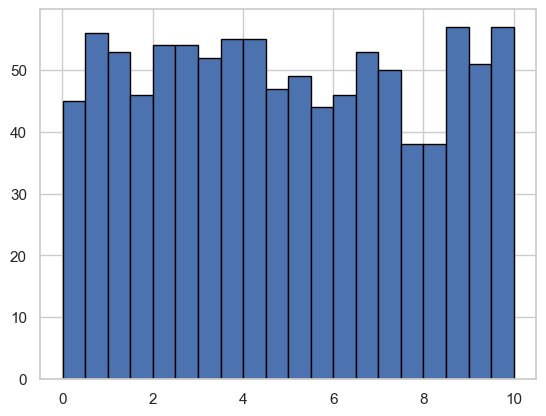

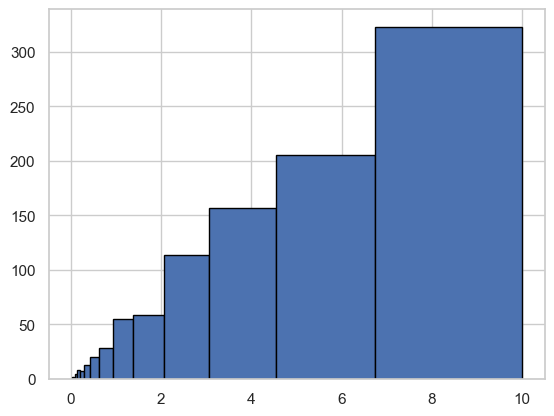

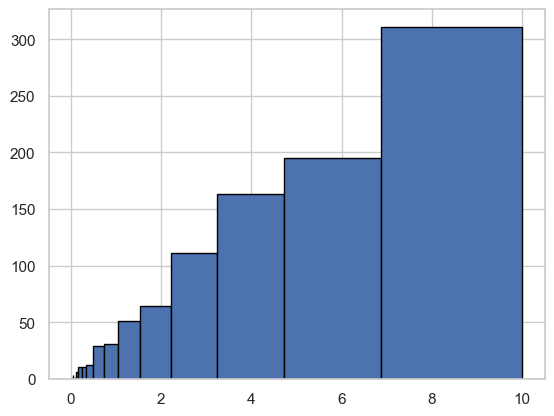

In [9]:
"""https://blog.finxter.com/5-best-ways-to-create-logarithmic-bins-in-a-python-histogram/
"""

# data = np.random.exponential(scale=1.0, size=1000)
# data = np.random.uniform(low=-1.0, high=1.0, size=1000)
data = np.random.uniform(low=.0, high=10.0, size=1000)


print(data.min(), data.max())
plt.hist(data, bins=20, edgecolor='black')
# plt.xscale('log')
plt.show()

bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 20)
# bins = np.logspace(np.log10(max(data)), np.log10(min(data)), 20)


plt.hist(data, bins=bins, edgecolor='black')
# plt.xscale('log')
plt.show()

def custom_log_binning(data, num_bins):
    log_min = np.log10(min(data))
    log_max = np.log10(max(data))
    bins = np.logspace(log_min, log_max, num_bins+1)
    return bins

# data = np.random.exponential(scale=1.0, size=1000)
bins = custom_log_binning(data, 20)

plt.hist(data, bins=bins, edgecolor='black')
# plt.xscale('log')
plt.show()

In [10]:
# h1?
# binnings.bayesian_blocks_binning?
# binnings.exponential_binning?
# np.logspace?
# np.geomspace?


['numpy', 'pretty', 'human', 'quantile', 'static', 'integer', 'fixed_width', 'exponential', 'blocks', 'knuth', 'scott', 'freedman'] 12


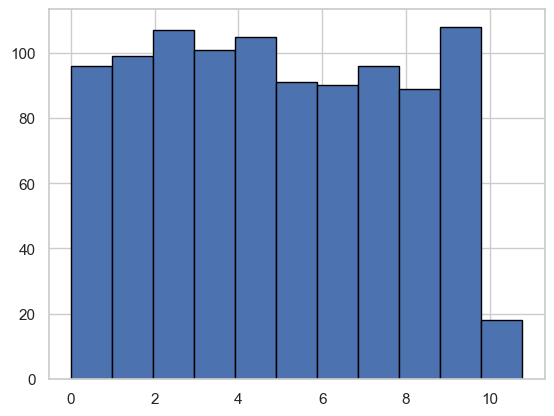

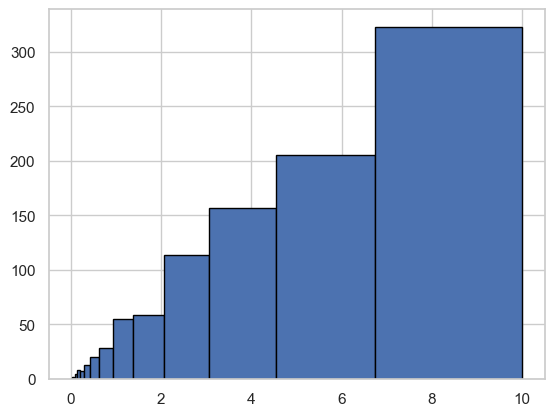

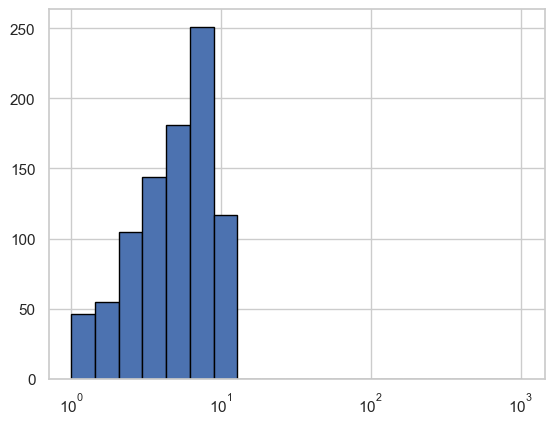

In [11]:
# import functools, itertools
# for v1, v2 in itertools.product([False, True], [False, True]):
#     print( v1, v2)

print(list(binnings.binning_methods.keys()), len(list(binnings.binning_methods.keys()))   )

# print(data)
# bbins = h1(data, "exponential", bin_count=20).numpy_bins

# bbins = binnings.exponential_binning(data, bin_count=20, range=(data.min(),data.max())).numpy_bins
# bbins = binnings.fixed_width_binning(data, bin_width=0.1).numpy_bins
bbins = binnings.freedman_binning(data, ).numpy_bins
# bbins = binnings.human_binning(data, bin_count=20).numpy_bins
# bbins = binnings.integer_binning(data,bin_width=0.1).numpy_bins
# bbins = binnings.knuth_binning(data,).numpy_bins
# bbins = binnings.numpy_binning(data, bin_count=20).numpy_bins
# bbins = binnings.pretty_binning(data, bin_count=20).numpy_bins
# bbins = binnings.quantile_binning(data, bin_count=20).numpy_bins
# bbins = binnings.scott_binning(data, ).numpy_bins
# bbins = binnings.static_binning(data, ).numpy_bins # errors
# bbins = binnings.bayesian_blocks_binning(data,).numpy_bins # errors sometimes

# bbins = h1(data, bins=20).numpy_bins

### numpy 
bbins_3 = np.logspace(data.min(), data.max(), 20, base=2) 
# bbins_3_2 = 2**bbins_3

bbins_2 = np.geomspace(data.min(), data.max(), 20,) 

plt.hist(data, bins=bbins, edgecolor='black')
# plt.xscale('log')
plt.show()

plt.hist(data, bins=bbins_2, edgecolor='black')
# plt.xscale('log')
plt.show()

plt.hist(data, bins=bbins_3, edgecolor='black')
plt.xscale('log')
plt.show()

# plt.hist(data, bins=bbins_3_2, edgecolor='black')
# plt.xscale('log')
# plt.show()

In [12]:
# np.logspace?
# np.geomspace?

In [13]:
print(data.min(), data.max())
print()
print(bbins.min(), bbins.max(), bbins[1]-bbins[0], bbins[2]-bbins[1])
print()
print(bbins_3.min(), bbins_3.max(), bbins_3[1]-bbins_3[0], bbins_3[2]-bbins_3[1])
print()
print(bbins_2.min(), bbins_2.max(), bbins_2[1]-bbins_2[0], bbins_2[2]-bbins_2[1])

0.005459648969956543 9.998085781169653

0.005459648969956543 10.7776908136512 0.9792937422437493 0.9792937422437493

1.0037915099473769 1022.6422215389749 0.441526880353982 0.6357365186536124

0.005459648969956543 9.998085781169653 0.002647880150316223 0.003932077967615541


In [14]:
print(bbins[1]/bbins[0], bbins[2]/bbins[1], bbins[3]/bbins[2])
print()
print(bbins_3[1]/bbins_3[0], bbins_3[2]/bbins_3[1], bbins_3[3]/bbins_3[2])
print()
print(bbins_2[1]/bbins_2[0], bbins_2[2]/bbins_2[1], bbins_2[3]/bbins_2[2])

180.36936012418104 1.9944558211033652 1.498610102355246

1.4398591500112696 1.4398591500112699 1.4398591500112696

1.4849909151461984 1.4849909151461982 1.484990915146197


In [15]:
print( (bbins[2]-bbins[1])/(bbins[1]-bbins[0]), (bbins[3]-bbins[2])/(bbins[2]-bbins[1]), (bbins[4]-bbins[3])/(bbins[3]-bbins[2]) )
print()
print( (bbins_3[2]-bbins_3[1])/(bbins_3[1]-bbins_3[0]), (bbins_3[3]-bbins_3[2])/(bbins_3[2]-bbins_3[1]), (bbins_3[4]-bbins_3[3])/(bbins_3[3]-bbins_3[2]) )
print()
print( (bbins_2[2]-bbins_2[1])/(bbins_2[1]-bbins_2[0]), (bbins_2[3]-bbins_2[2])/(bbins_2[2]-bbins_2[1]), (bbins_2[4]-bbins_2[3])/(bbins_2[3]-bbins_2[2]) )

1.0 1.0 1.0

1.4398591500112703 1.4398591500112696 1.4398591500112692

1.4849909151461982 1.4849909151461949 1.4849909151462002


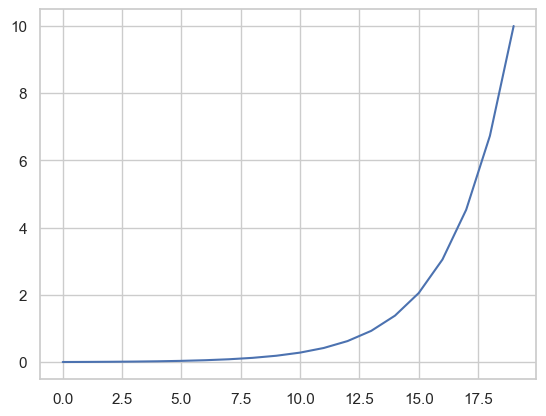

In [16]:
# plt.plot(bbins)
plt.plot(bbins_2)
# plt.plot(bbins_3)


# Custom binnings

In [17]:
# def create_bins(start:float, stop:float, n_bins:int, power:float=1.0, smoothing:bool=False) -> np.ndarray:
#     if power <= 0. or power > 3.:
#         raise ValueError("power/alpha must be a strictly positive float number less than or equal to 3. i.e \in ]0.0; 3.]!")
#     elif power==1.:
#         return np.linspace(start,stop,n_bins+1, endpoint=True)
#     else:
#         # Map to [0,1] using norm_x = (x - x_min) / (x_max - x_min), then apply power transformation
#         # norm_x = (x - x_min) / (x_max - x_min)
#         if smoothing:
#             if power<1.:
#                 bins_transformed = np.linspace(0, 1, n_bins + 1, endpoint=True) ** (power**(1./3.))
#                 bins = bins_transformed * (stop - start) + start
#                 return bins
#             elif power>1.:
#                 bins_transformed = np.linspace(0, 1, n_bins + 1, endpoint=True) ** (power**(4./5.))
#                 bins = bins_transformed * (stop - start) + start
#                 return bins
#         else:
#             bins_transformed = np.linspace(0, 1, n_bins + 1, endpoint=True) ** power
#             bins = bins_transformed * (stop - start) + start
#             return bins

In [18]:
(
    np.arange(1.,2.01,.05),
    np.arange(0.0,1.01,.05)**(1./3.),
    np.arange(1.,5.01,.05)**(4/5.),
)

(array([1.  , 1.05, 1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 ,
        1.55, 1.6 , 1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  ]),
 array([0.        , 0.36840315, 0.46415888, 0.53132928, 0.58480355,
        0.62996052, 0.66943295, 0.70472987, 0.7368063 , 0.76630943,
        0.79370053, 0.81932127, 0.84343267, 0.86623911, 0.887904  ,
        0.9085603 , 0.92831777, 0.94726824, 0.96548938, 0.98304757,
        1.        ]),
 array([1.        , 1.03980389, 1.07923035, 1.11829986, 1.157031  ,
        1.19544062, 1.2335441 , 1.27135553, 1.30888783, 1.34615293,
        1.38316187, 1.41992485, 1.45645136, 1.49275026, 1.52882979,
        1.56469768, 1.60036117, 1.63582704, 1.6711017 , 1.70619117,
        1.74110113, 1.77583695, 1.81040373, 1.84480628, 1.87904917,
        1.91313675, 1.94707315, 1.98086232, 2.01450799, 2.04801375,
        2.08138302, 2.11461907, 2.14772503, 2.18070389, 2.21355854,
        2.24629171, 2.27890607, 2.31140415, 2.34378839, 2.37606115,
        2.40822469

In [19]:
np.arange(0.,5.01,.05)

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
       1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
       1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
       2.2 , 2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 ,
       2.75, 2.8 , 2.85, 2.9 , 2.95, 3.  , 3.05, 3.1 , 3.15, 3.2 , 3.25,
       3.3 , 3.35, 3.4 , 3.45, 3.5 , 3.55, 3.6 , 3.65, 3.7 , 3.75, 3.8 ,
       3.85, 3.9 , 3.95, 4.  , 4.05, 4.1 , 4.15, 4.2 , 4.25, 4.3 , 4.35,
       4.4 , 4.45, 4.5 , 4.55, 4.6 , 4.65, 4.7 , 4.75, 4.8 , 4.85, 4.9 ,
       4.95, 5.  ])

In [20]:
(
    np.arange(1.,2.01,.1),
    np.arange(1.,2.01,.1)**(4./5.),
    np.arange(1.,.01,-.1),
    np.arange(1.,.01,-.1)**(1./3.),
)

(array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ]),
 array([1.        , 1.07923035, 1.157031  , 1.2335441 , 1.30888783,
        1.38316187, 1.45645136, 1.52882979, 1.60036117, 1.6711017 ,
        1.74110113]),
 array([1. , 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]),
 array([1.        , 0.96548938, 0.92831777, 0.887904  , 0.84343267,
        0.79370053, 0.7368063 , 0.66943295, 0.58480355, 0.46415888]))

In [21]:
arr = np.arange(1.,2.01,.1)**(4./5.)
arr1 = np.arange(1.,.01,-.1)**(1./3.)

bins_disp = [j-i for (i,j) in zip(arr[:-1], arr[1:])]
bins_2_disp = [j-i for (i,j) in zip(arr1[:-1], arr1[1:])]

(
    bins_disp,
    bins_2_disp,
)

([0.07923034529889095,
  0.07780065950426174,
  0.07651309926802163,
  0.0753437225366842,
  0.07427404061473353,
  0.07328949519827255,
  0.07237842945101303,
  0.07153137316608293,
  0.07074053398818125,
  0.06999942756610711],
 [-0.03451061539437028,
  -0.03717161788307388,
  -0.04041376497995508,
  -0.04447133644085144,
  -0.049732139317649526,
  -0.05689422625602236,
  -0.0673733496459078,
  -0.08462940243959627,
  -0.12064466428129517])

In [22]:
print(
    np.arange(.05, 3.01, .05).shape[0],
    np.arange(.05, 3.01, .1).shape[0],
    "--------------------------------",
    np.arange(.05, 3.01, .05),
    "OR",
    np.arange(.2, 2.01, .1),#.shape[0],
)
# np.arange?
# np.linspace?

60 30 -------------------------------- [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4
 1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05 2.1
 2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75 2.8
 2.85 2.9  2.95 3.  ] OR [0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9
 2. ]


In [23]:
([.025, .05, .075] ,
np.array(list(range(1,10,1)))/10. ,
np.array(list(range(10,20,1)))/10. ,
np.array(list(range(20,31,2)))/10. ,
)

([0.025, 0.05, 0.075],
 array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
 array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9]),
 array([2. , 2.2, 2.4, 2.6, 2.8, 3. ]))

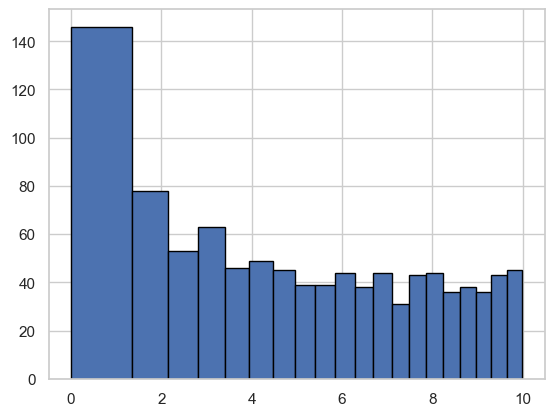

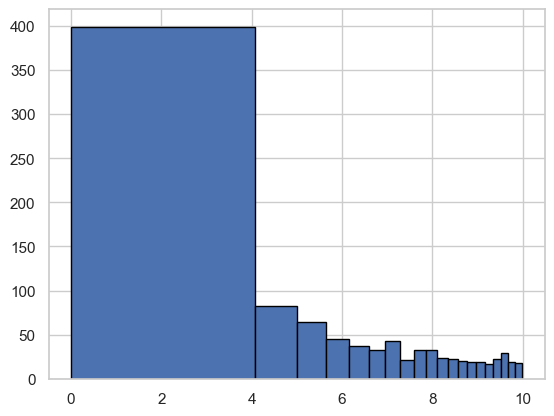

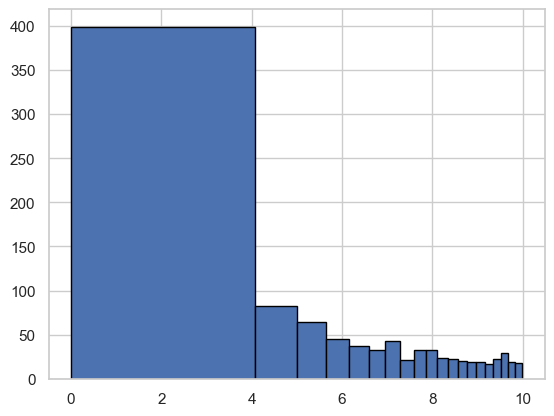

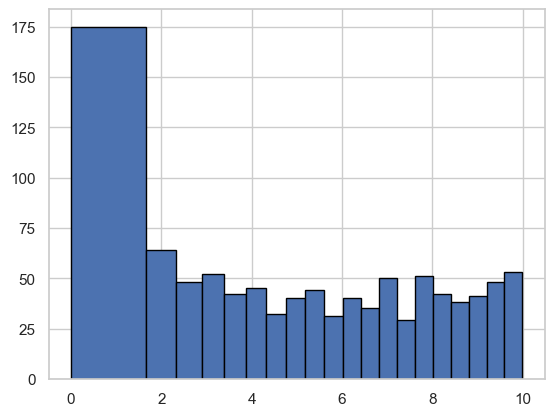

In [169]:
# strength = 1.5 # advice 1.0-1.0?
strength = .3 # advice .2-.7?
# strength = 2.8
# strength = 1. # advice .2-.7?
# strength = 1.5 #

# data = np.random.uniform(low=.0, high=10.0, size=1000)

bins_ = create_bins(data.min(), data.max(), n_bins=20, alpha=strength, smoothing=True)
plt.hist(data, bins=bins_, edgecolor='black')
# plt.xscale('log')
plt.show()

bins_4 = create_bins(data.min(), data.max(), n_bins=20, alpha=strength, smoothing=False)
plt.hist(data, bins=bins_4, edgecolor='black')
# plt.xscale('log')
plt.show()

bins_3 = nonlinear_binning(data, n_bins=20, method="power", strength=strength)
plt.hist(data, bins=bins_3, edgecolor='black')
# plt.xscale('log')
plt.show()

bins_2 = nonlinear_binning(data, n_bins=20, method="log", strength=strength)
plt.hist(data, bins=bins_2, edgecolor='black')
# plt.xscale('log')
plt.show()

In [170]:
print(len(data), data.min(), data.max())

print(len(bins_), bins_.min(), bins_.max())

print(len(bins_2), bins_2.min(), bins_2.max())

1000 0.0036734375145786036 9.985265777083542
21 0.0036734375145786036 9.985265777083542
21 0.0036734375145786036 9.985265777083542


In [171]:
print(bbins_2.min(), bbins_2.max(), bbins_2[1]-bbins_2[0], bbins_2[2]-bbins_2[1])
print()
print(bins_[1]/bins_[0], bins_[2]/bins_[1], bins_[3]/bins_[2])
print()
print(bins_4[1]/bins_4[0], bins_4[2]/bins_4[1], bins_4[3]/bins_4[2])
print()
print(bins_3[1]/bins_3[0], bins_3[2]/bins_3[1], bins_3[3]/bins_3[2])
print()
print(bins_2[1]/bins_2[0], bins_2[2]/bins_2[1], bins_2[3]/bins_2[2])

0.005459648969956543 9.998085781169653 0.002647880150316223 0.003932077967615541

366.74199017896274 1.5888377394423983 1.3113061025621302

1107.160568942182 1.2309356410856533 1.1292520258472782

1107.160568942182 1.2309356410856533 1.1292520258472782

451.5038536710528 1.4047823012633396 1.2398229651811992


In [172]:
print( (bbins_2[2]-bbins_2[1])/(bbins_2[1]-bbins_2[0]), (bbins_2[3]-bbins_2[2])/(bbins_2[2]-bbins_2[1]), (bbins_2[4]-bbins_2[3])/(bbins_2[3]-bbins_2[2]) )
print()
print( (bins_[2]-bins_[1])/(bins_[1]-bins_[0]), (bins_[3]-bins_[2])/(bins_[2]-bins_[1]), (bins_[4]-bins_[3])/(bins_[3]-bins_[2]) )
print()
print( (bins_4[2]-bins_4[1])/(bins_4[1]-bins_4[0]), (bins_4[3]-bins_4[2])/(bins_4[2]-bins_4[1]), (bins_4[4]-bins_4[3])/(bins_4[3]-bins_4[2]) )
print()
print( (bins_3[2]-bins_3[1])/(bins_3[1]-bins_3[0]), (bins_3[3]-bins_3[2])/(bins_3[2]-bins_3[1]), (bins_3[4]-bins_3[3])/(bins_3[3]-bins_3[2]) )
print()
print( (bins_2[2]-bins_2[1])/(bins_2[1]-bins_2[0]), (bins_2[3]-bins_2[2])/(bins_2[2]-bins_2[1]), (bins_2[4]-bins_2[3])/(bins_2[3]-bins_2[2]) )

1.4849909151461982 1.4849909151461949 1.4849909151462002

0.590447720673031 0.8399850266693424 0.8934238946846196

0.23114441334491628 0.6889405401002121 0.7870111304029752

0.23114441334491628 0.6889405401002121 0.7870111304029752

0.4056808114491347 0.8322969059456626 0.90367059819682


In [173]:
print( (bbins_2[1]-bbins_2[0]), (bbins_2[2]-bbins_2[1]), (bbins_2[3]-bbins_2[2]) )
print()
print( (bins_[1]-bins_[0]), (bins_[2]-bins_[1]), (bins_[3]-bins_[2]) )
print()

0.002647880150316223 0.003932077967615541 0.005839100059555591

1.3435303473800408 0.7932844312655907 0.6663470441530013



In [174]:
bins_disp = [j-i for (i,j) in zip(bins_[:-1], bins_[1:])]
bins_2_disp = [j-i for (i,j) in zip(bins_2[:-1], bins_2[1:])]

(
    bins_disp,
    bins_2_disp,
)

([1.3435303473800408,
  0.7932844312655907,
  0.6663470441530013,
  0.5953303713987586,
  0.5475437114564006,
  0.5122464260939514,
  0.4846419147362502,
  0.4621999175023337,
  0.4434346126120108,
  0.4274050352426739,
  0.4134807367385811,
  0.40122042406545155,
  0.3903042012406859,
  0.3804934273941951,
  0.37160576497740383,
  0.36349904030944735,
  0.35606044813937565,
  0.34919912075692494,
  0.3428408846210118,
  0.3369244794848747],
 [1.6548977565374752,
  0.6713602647374755,
  0.5587710711158618,
  0.5049449880903487,
  0.472897080162646,
  0.4516804088821247,
  0.4367406664655036,
  0.4258043963355229,
  0.4175963838071626,
  0.41134035914948797,
  0.40653412104240516,
  0.4028370801320822,
  0.400009378997086,
  0.3978768104433952,
  0.3963095539432526,
  0.3952087371327977,
  0.39449763839911967,
  0.39411575191328296,
  0.39401467829482506,
  0.3941552139871085])

In [175]:
bins_disp[0]/(data.max()-data.min()) , bins_disp[-1]/(data.max()-data.min())

(0.1346008033261413, 0.03375458223726898)

In [176]:
bins_2_disp[0]/(data.max()-data.min()) , bins_2_disp[-1]/(data.max()-data.min())


(0.1657949653961663, 0.03948820995469841)

In [177]:
bins_.max(), data.max()

(9.985265777083542, 9.985265777083542)

# Linear binning

In [178]:
import numpy as np
def linear_binning_edges(x_min, x_max, n_bins, use_numpy=True):
    u = None
    if use_numpy:
        u = np.linspace(0, 1, n_bins + 1)      # normalized bin coordinates
    else:
        u = np.arange(n_bins+1)/n_bins
    bins = x_min + (x_max - x_min) * u      # map to data range
    return bins

x_min, x_max, n_bins = -.33, 4.67, 20
(linear_binning_edges(x_min, x_max, n_bins, use_numpy=True) == linear_binning_edges(x_min, x_max, n_bins, use_numpy=False)).all()

False

In [179]:
(
    linear_binning_edges(x_min, x_max, n_bins, use_numpy=True),
    linear_binning_edges(x_min, x_max, n_bins, use_numpy=False)
)

(array([-0.33, -0.08,  0.17,  0.42,  0.67,  0.92,  1.17,  1.42,  1.67,
         1.92,  2.17,  2.42,  2.67,  2.92,  3.17,  3.42,  3.67,  3.92,
         4.17,  4.42,  4.67]),
 array([-0.33, -0.08,  0.17,  0.42,  0.67,  0.92,  1.17,  1.42,  1.67,
         1.92,  2.17,  2.42,  2.67,  2.92,  3.17,  3.42,  3.67,  3.92,
         4.17,  4.42,  4.67]))

In [180]:
def f(j,k,alpha,epsilon=1):
    return u(j,k)**(alpha*epsilon)
    
def u(j,k):
    return j/k

k, alpha = 20, 2.

u(10,k) , f(10,k,alpha)

(0.5, 0.25)

In [181]:
k=20
width = (data.max()-data.min())/20
width
u_arr = np.array([data.min()+j*width for j in range(0,k+1)])
# u_arr.shape

In [182]:
k=20

arr = np.linspace(0,1,k+1, endpoint=True) 
arr , np.array([j/k for j in range(0,k+1)])

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]))

In [183]:
(arr == u_arr).all()

False

In [184]:
def KG(k,alpha,epsilon=1., x_min=0, x_max=10, power_reg=False):
    # width = (data.max()-data.min())/20
    # u = np.array([j*width for j in range(0,k+1)])
    u = np.array([j/k for j in range(0,k+1)])
    bins = None
    if power_reg:
        bins = x_min + (x_max - x_min) * u**(alpha**epsilon) # Square root
    else:
        bins = x_min + (x_max - x_min) * u**(alpha*epsilon) # Multiplication 
    
    return bins

# binss = KG(20,alpha=strength,epsilon=4./5., x_min=data.min(), x_max=data.max())
# binss_2 = KG(20,alpha=strength,epsilon=4./5., x_min=data.min(), x_max=data.max(), power_reg=True)

binss = KG(20,alpha=strength,epsilon=1./3., x_min=data.min(), x_max=data.max())
binss_2 = KG(20,alpha=strength,epsilon=1./3., x_min=data.min(), x_max=data.max(), power_reg=True)

# binss = KG(k,alpha=strength,epsilon=1., x_min=data.min(), x_max=data.max())

binss

array([3.67343751e-03, 7.40137538e+00, 7.93233406e+00, 8.26042001e+00,
       8.50140149e+00, 8.69315427e+00, 8.85303530e+00, 8.99050565e+00,
       9.11131285e+00, 9.21921963e+00, 9.31682840e+00, 9.40601660e+00,
       9.48818464e+00, 9.56440588e+00, 9.63552171e+00, 9.70220437e+00,
       9.76499967e+00, 9.82435708e+00, 9.88065129e+00, 9.93419799e+00,
       9.98526578e+00])

In [185]:
print(data.min(), data.max())
print()
print(binss.min(), binss.max(), binss[1]-binss[0], binss[2]-binss[1])
print()
print( (binss[2]-binss[1])/(binss[1]-binss[0]), (binss[3]-binss[2])/(binss[2]-binss[1]), (binss[4]-binss[3])/(binss[3]-binss[2]) )
print()
print( (bins_[2]-bins_[1])/(bins_[1]-bins_[0]), (bins_[3]-bins_[2])/(bins_[2]-bins_[1]), (bins_[4]-bins_[3])/(bins_[3]-bins_[2]) )
print()
print( (bbins_2[2]-bbins_2[1])/(bbins_2[1]-bbins_2[0]), (bbins_2[3]-bbins_2[2])/(bbins_2[2]-bbins_2[1]), (bbins_2[4]-bbins_2[3])/(bbins_2[3]-bbins_2[2]) )


0.0036734375145786036 9.985265777083542

0.0036734375145786036 9.985265777083542 7.3977019397965735 0.5309586830306525

0.07177346253629314 0.6179123861439072 0.7345071673101015

0.590447720673031 0.8399850266693424 0.8934238946846196

1.4849909151461982 1.4849909151461949 1.4849909151462002


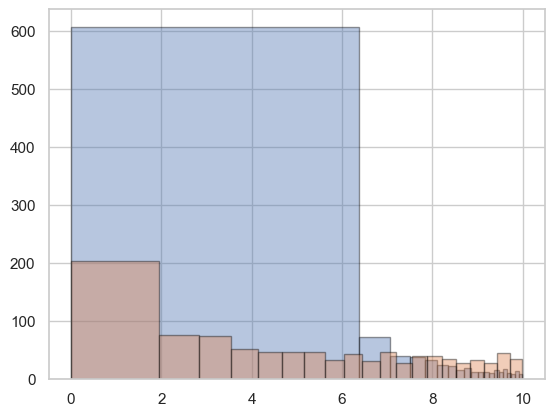

In [198]:
epsilon = .5
binss = KG(20,alpha=strength,epsilon=epsilon, x_min=data.min(), x_max=data.max())
binss_2 = KG(20,alpha=strength,epsilon=epsilon, x_min=data.min(), x_max=data.max(), power_reg=True)

plt.hist(data, bins=binss, edgecolor='black', alpha=0.4)
plt.hist(data, bins=binss_2, edgecolor='black', alpha=0.4)
# plt.hist(data, bins=bins_, edgecolor='black', alpha=0.4)
# plt.hist(data, bins=bbins_2, edgecolor='black', alpha=0.4)

# plt.xscale('log')
plt.show()

In [35]:
for i in range(1,k+1):
    print(u(i,k) , f(i,k,alpha))

0.05 0.0025000000000000005
0.1 0.010000000000000002
0.15 0.0225
0.2 0.04000000000000001
0.25 0.0625
0.3 0.09
0.35 0.12249999999999998
0.4 0.16000000000000003
0.45 0.2025
0.5 0.25
0.55 0.30250000000000005
0.6 0.36
0.65 0.42250000000000004
0.7 0.48999999999999994
0.75 0.5625
0.8 0.6400000000000001
0.85 0.7224999999999999
0.9 0.81
0.95 0.9025
1.0 1.0


In [36]:
np.arange(0, 3.01, 0.05).shape

(61,)